# VR Rautatieliikenne — Täsmällisyysanalyysi

Tämä notebook visualisoi junaliikenteen täsmällisyystietoja VR-tietoalustasta.

**Vaatimukset ennen ajamista:**
1. Aja dataputki: `python 01_fetch/fetch_trains.py && python 03_bronze/bronze.py && python 04_silver/silver.py`
2. Aja dbt-mallit: `cd 06_transform && dbt run`

**Käyttö:**  
Aja solut järjestyksessä (Cell → Run All). Muuta alla olevia muuttujia tarpeen mukaan.

## ⚙️ Asetukset — muuta tarvittaessa

Nämä muuttujat vaikuttavat visualisointeihin. Muokkaa vapaasti!

In [33]:
# 👇 MUUTA NÄITÄ — muut solut mukautuvat automaattisesti

# Tietokannan polku (suhteessa tähän notebookiin)
DUCKDB_PATH = "../04_silver/vr_warehouse.duckdb"

# Kuinka monta asemaa näytetään top/bottom-listoissa
TOP_N_STATIONS = 10

# Suodatus: näytetään vain asemat joilla on vähintään N pysähdystä
MIN_STOP_COUNT = 50

# Myöhästymisen raja täsmällisyyslaskennassa (minuuttia)
# VR:n virallinen raja kaukoliikenteessä on 3 minuuttia
LATE_THRESHOLD_MINUTES = 3

In [34]:
# Kirjastojen tuonti
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd

# Visuaalinen tyyli
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Yhdistetään tietokantaan
conn = duckdb.connect(DUCKDB_PATH, read_only=True)
print(f"Yhdistetty: {DUCKDB_PATH}")

# Tarkistetaan mitä tauluja on saatavilla
tables = conn.execute("SHOW TABLES").df()
print(f"Taulut ({len(tables)} kpl):")
print(tables["name"].tolist())

Yhdistetty: ../04_silver/vr_warehouse.duckdb
Taulut (1 kpl):
['bronze_stops']


## Tietokannan rakenne

Alla näkyvät kaikki silver- ja gold-kerrosten taulut ja sarakkeet suoraan DuckDB:stä.

In [ ]:
schema = conn.execute("""
    SELECT
        table_schema   AS kerros,
        table_name     AS taulu,
        column_name    AS sarake,
        data_type      AS tyyppi
    FROM information_schema.columns
    WHERE table_schema IN ('silver', 'gold')
    ORDER BY table_schema DESC, table_name, ordinal_position
""").df()

schema.style.set_properties(**{"text-align": "left"}).hide(axis="index")

## 1. Yleiskatsaus

In [35]:
# Perustilastot
summary = conn.execute("""
    SELECT
        COUNT(DISTINCT departure_date)   AS paivia,
        COUNT(DISTINCT train_key)        AS junavuoroja,
        COUNT(*)                         AS pysahdyksia,
        MIN(departure_date)              AS ensimmainen_paiva,
        MAX(departure_date)              AS viimeinen_paiva,
        ROUND(AVG(CASE WHEN difference_minutes > 0 THEN difference_minutes END), 1)
                                         AS keskim_myohastyminen_min
    FROM silver.fact_train_stops
    WHERE actual_time IS NOT NULL
""").df()

print("=== Datan yleiskatsaus ===")
for col in summary.columns:
    print(f"  {col}: {summary[col].iloc[0]}")

=== Datan yleiskatsaus ===
  paivia: 7
  junavuoroja: 11429
  pysahdyksia: 441763
  ensimmainen_paiva: 2026-04-13 00:00:00
  viimeinen_paiva: 2026-04-19 00:00:00
  keskim_myohastyminen_min: 3.2


## 2. Päivittäinen täsmällisyys

Kuinka monta prosenttia junista saapui ajoissa päivittäin?

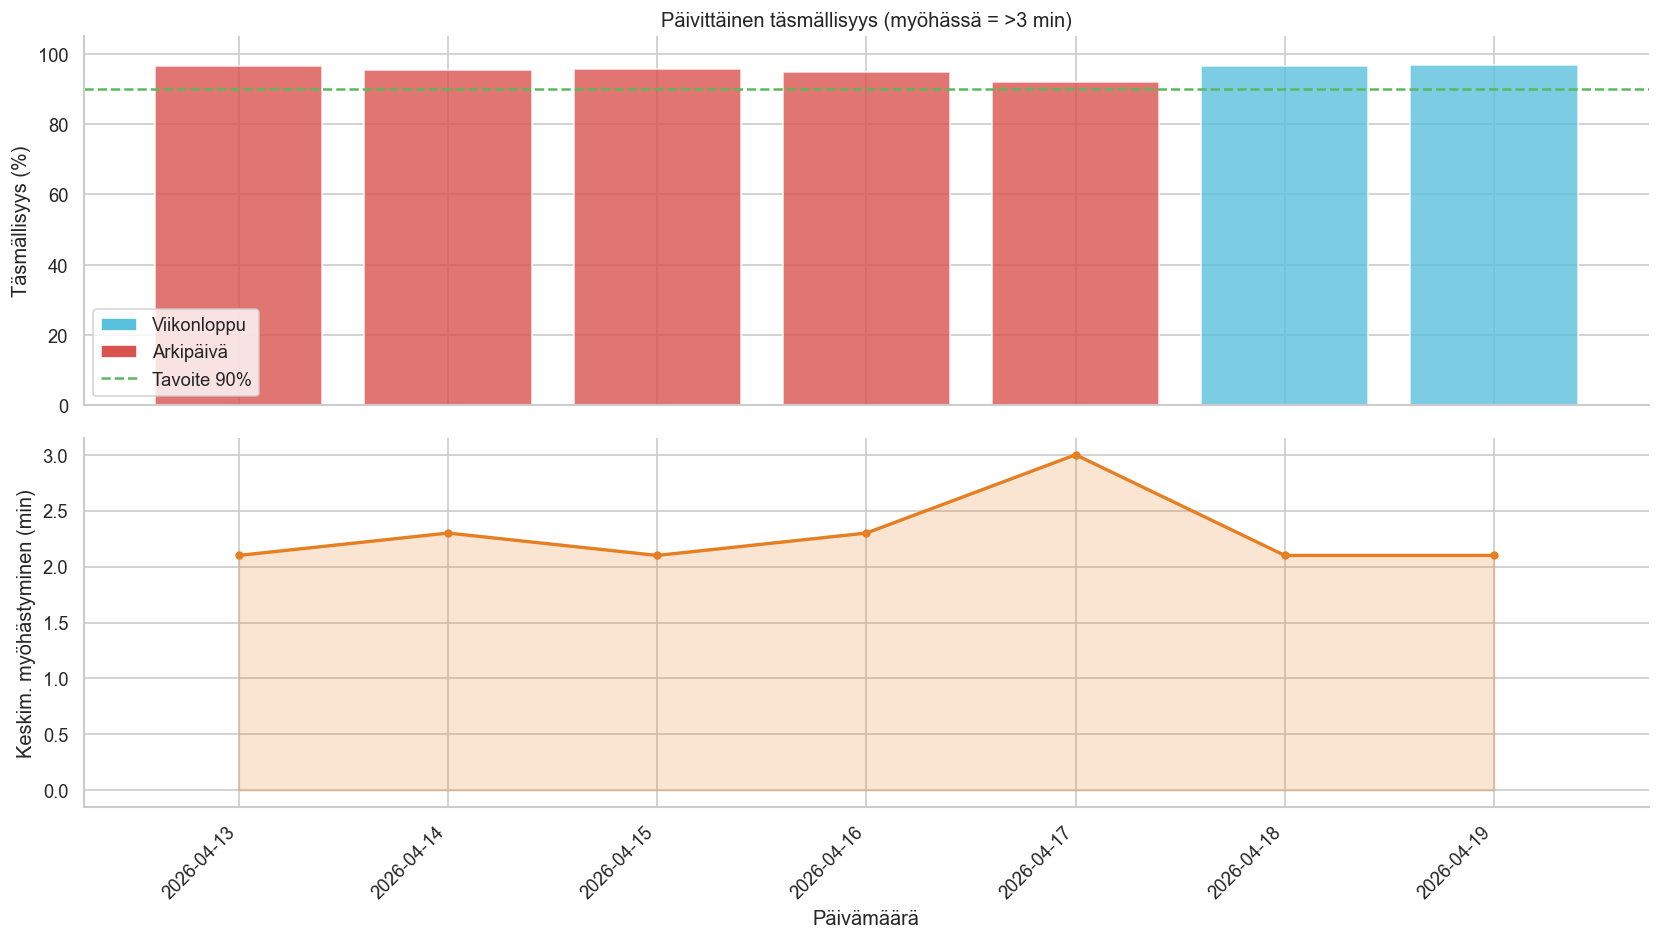

Kuva tallennettu: daily_punctuality.png


In [36]:
daily = conn.execute("""
    SELECT
        departure_date,
        punctuality_pct,
        avg_delay_minutes,
        total_trains,
        day_name,
        is_weekend
    FROM gold.gold_daily_punctuality
    ORDER BY departure_date
""").df()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Ylärivi: täsmällisyysprosentti
colors = ["#d9534f" if not wknd else "#5bc0de" for wknd in daily["is_weekend"]]
ax1.bar(daily["departure_date"], daily["punctuality_pct"], color=colors, alpha=0.8)
ax1.axhline(y=90, color="#5cb85c", linestyle="--", linewidth=1.5, label="Tavoite 90%")
ax1.set_ylabel("Täsmällisyys (%)")
ax1.set_title(f"Päivittäinen täsmällisyys (myöhässä = >{LATE_THRESHOLD_MINUTES} min)")
ax1.set_ylim(0, 105)
ax1.legend()

# Alarivi: keskimääräinen myöhästyminen
ax2.plot(daily["departure_date"], daily["avg_delay_minutes"],
         color="#e67e22", linewidth=2, marker="o", markersize=4)
ax2.fill_between(daily["departure_date"], daily["avg_delay_minutes"], alpha=0.2, color="#e67e22")
ax2.set_ylabel("Keskim. myöhästyminen (min)")
ax2.set_xlabel("Päivämäärä")

# Legenda viikonlopuille
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#5bc0de", label="Viikonloppu"),
    Patch(facecolor="#d9534f", label="Arkipäivä"),
]
ax1.legend(handles=legend_elements + [plt.Line2D([0], [0], color="#5cb85c", linestyle="--", label="Tavoite 90%")])

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("daily_punctuality.png", bbox_inches="tight")
plt.show()
print("Kuva tallennettu: daily_punctuality.png")

## 3. Asemakohtainen täsmällisyys

Millä asemilla junat ovat täsmällisimpiä ja epätäsmällisimpiä?

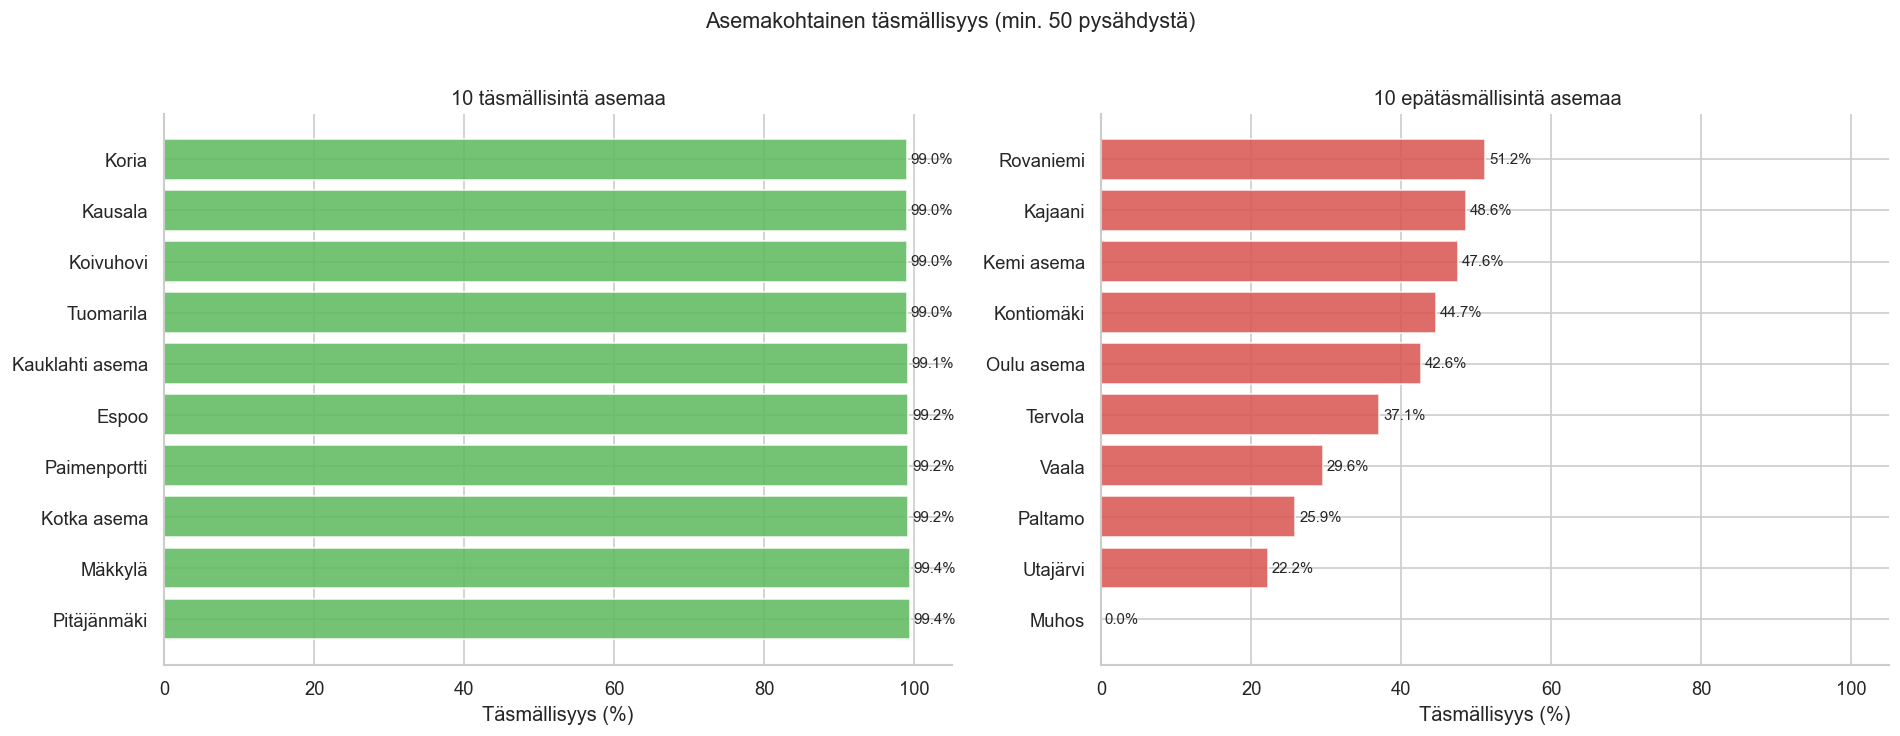

In [37]:
station_data = conn.execute(f"""
    SELECT
        station_name,
        station_code,
        punctuality_pct,
        avg_delay_minutes,
        stop_count
    FROM gold.gold_station_punctuality
    WHERE stop_count >= {MIN_STOP_COUNT}
    ORDER BY punctuality_pct DESC
""").df()

# Top N täsmällisintä
best = station_data.head(TOP_N_STATIONS)
# Bottom N epätäsmällisintä
worst = station_data.tail(TOP_N_STATIONS).sort_values("punctuality_pct")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Täsmällisimmät
bars1 = ax1.barh(best["station_name"], best["punctuality_pct"],
                  color="#5cb85c", alpha=0.85)
ax1.set_xlabel("Täsmällisyys (%)")
ax1.set_title(f"{TOP_N_STATIONS} täsmällisintä asemaa")
ax1.set_xlim(0, 105)
for bar, val in zip(bars1, best["punctuality_pct"]):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", fontsize=9)

# Epätäsmällisimmät
bars2 = ax2.barh(worst["station_name"], worst["punctuality_pct"],
                  color="#d9534f", alpha=0.85)
ax2.set_xlabel("Täsmällisyys (%)")
ax2.set_title(f" {TOP_N_STATIONS} epätäsmällisintä asemaa")
ax2.set_xlim(0, 105)
for bar, val in zip(bars2, worst["punctuality_pct"]):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", fontsize=9)

plt.suptitle(f"Asemakohtainen täsmällisyys (min. {MIN_STOP_COUNT} pysähdystä)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("station_punctuality.png", bbox_inches="tight")
plt.show()

## 4. Myöhästymisjakauma

Miten myöhästymiset jakautuvat? Ovatko ne tyypillisesti pieniä vai suuria?

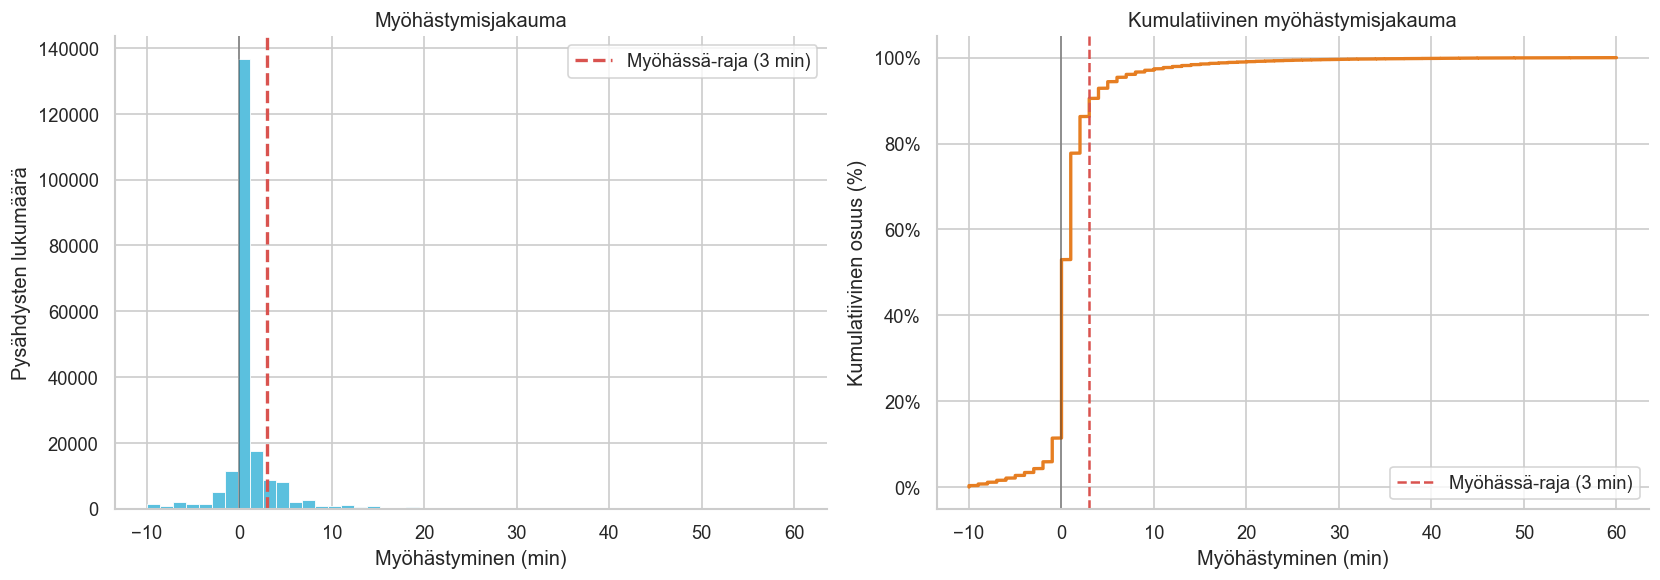

Mediaani myöhästyminen: 0.0 min
95. prosenttipiste: 6.0 min
Myöhässä (>3 min): 9.5%


In [38]:
delays = conn.execute("""
    SELECT difference_minutes
    FROM silver.fact_train_stops
    WHERE stop_type = 'ARRIVAL'
      AND actual_time IS NOT NULL
      AND difference_minutes IS NOT NULL
      AND difference_minutes BETWEEN -10 AND 60  -- poissuljettaan outlierit
""").df()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogrammi
ax1.hist(delays["difference_minutes"], bins=50,
         color="#5bc0de", edgecolor="white", linewidth=0.5)
ax1.axvline(x=LATE_THRESHOLD_MINUTES, color="#d9534f",
            linestyle="--", linewidth=2,
            label=f"Myöhässä-raja ({LATE_THRESHOLD_MINUTES} min)")
ax1.axvline(x=0, color="#333", linestyle="-", linewidth=1, alpha=0.5)
ax1.set_xlabel("Myöhästyminen (min)")
ax1.set_ylabel("Pysähdysten lukumäärä")
ax1.set_title("Myöhästymisjakauma")
ax1.legend()

# Kumulatiivinen jakauma (CDF)
sorted_delays = delays["difference_minutes"].sort_values()
cdf = range(1, len(sorted_delays) + 1)
ax2.plot(sorted_delays, [x/len(sorted_delays)*100 for x in cdf],
         color="#e67e22", linewidth=2)
ax2.axvline(x=LATE_THRESHOLD_MINUTES, color="#d9534f",
            linestyle="--", linewidth=1.5,
            label=f"Myöhässä-raja ({LATE_THRESHOLD_MINUTES} min)")
ax2.axvline(x=0, color="#333", linestyle="-", linewidth=1, alpha=0.5)
ax2.set_xlabel("Myöhästyminen (min)")
ax2.set_ylabel("Kumulatiivinen osuus (%)")
ax2.set_title("Kumulatiivinen myöhästymisjakauma")
ax2.legend()
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig("delay_distribution.png", bbox_inches="tight")
plt.show()

# Tilastot
print(f"Mediaani myöhästyminen: {delays['difference_minutes'].median():.1f} min")
print(f"95. prosenttipiste: {delays['difference_minutes'].quantile(0.95):.1f} min")
pct_late = (delays['difference_minutes'] > LATE_THRESHOLD_MINUTES).mean() * 100
print(f"Myöhässä (>{LATE_THRESHOLD_MINUTES} min): {pct_late:.1f}%")

## 5. Viikonpäivävertailu

Onko täsmällisyydessä eroja eri viikonpäivien välillä?

## 6. Vuorovaikutteinen asema-analyysi

Valitse asema pudotusvalikosta ja tarkastele sen täsmällisyyttä.

import ipywidgets as widgets
from IPython.display import display, clear_output

# Haetaan asemat joilla on tarpeeksi dataa
station_options = conn.execute(f"""
    SELECT station_name || ' (' || station_code || ')' AS label,
           station_code
    FROM gold.gold_station_punctuality
    WHERE stop_count >= {MIN_STOP_COUNT}
    ORDER BY station_name
""").df()

options = [(row["label"], row["station_code"]) for _, row in station_options.iterrows()]

# 👇 Valitse asema pudotusvalikosta
station_dropdown = widgets.Dropdown(
    options=options,
    description="Asema:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="350px")
)

output = widgets.Output()

def update_station_plot(change):
    station_code = change["new"]
    station_label = [l for l, c in options if c == station_code][0]

    with output:
        clear_output(wait=True)

        df = conn.execute(f"""
            SELECT
                f.departure_date,
                ROUND(AVG(CASE WHEN f.is_late = FALSE THEN 100.0 ELSE 0 END), 1)
                    AS punctuality_pct,
                COUNT(*) AS stops,
                ROUND(AVG(CASE WHEN f.difference_minutes > 0
                               THEN f.difference_minutes END), 1) AS avg_delay
            FROM silver.fact_train_stops f
            WHERE f.station_code = '{station_code}'
              AND f.stop_type = 'ARRIVAL'
              AND f.actual_time IS NOT NULL
              AND f.commercial_stop = TRUE
            GROUP BY f.departure_date
            ORDER BY f.departure_date
        """).df()

        if df.empty:
            print(f"Ei dataa asemalle {station_label}")
            return

        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(df["departure_date"], df["punctuality_pct"],
                color="#3498db", linewidth=2, marker="o", markersize=4)
        ax.fill_between(df["departure_date"], df["punctuality_pct"], alpha=0.15, color="#3498db")
        ax.axhline(y=90, color="#e74c3c", linestyle="--", linewidth=1.5, label="Tavoite 90%")
        ax.set_title(f"Päivittäinen täsmällisyys — {station_label}")
        ax.set_ylabel("Täsmällisyys (%)")
        ax.set_ylim(0, 105)
        ax.legend()
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

station_dropdown.observe(update_station_plot, names="value")

# Alustetaan näkymä ensimmäisellä asemalla
update_station_plot({"new": options[0][1]})

display(station_dropdown, output)

In [40]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Haetaan asemat joilla on tarpeeksi dataa
station_options = conn.execute(f"""
    SELECT station_name || ' (' || station_code || ')' AS label,
           station_code
    FROM gold.gold_station_punctuality
    WHERE stop_count >= {MIN_STOP_COUNT}
    ORDER BY station_name
""").df()

options = [(row["label"], row["station_code"]) for _, row in station_options.iterrows()]

# 👇 WIDGET: valitse asema dropdownista
station_dropdown = widgets.Dropdown(
    options=options,
    description="Asema:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="350px")
)

output = widgets.Output()

def update_station_plot(change):
    station_code = change["new"]
    station_label = [l for l, c in options if c == station_code][0]

    with output:
        clear_output(wait=True)

        # Haetaan päivittäinen data valitulle asemalle
        df = conn.execute(f"""
            SELECT
                f.departure_date,
                ROUND(AVG(CASE WHEN f.is_late = FALSE THEN 100.0 ELSE 0 END), 1)
                    AS punctuality_pct,
                COUNT(*) AS stops,
                ROUND(AVG(CASE WHEN f.difference_minutes > 0
                               THEN f.difference_minutes END), 1) AS avg_delay
            FROM silver.fact_train_stops f
            WHERE f.station_code = '{station_code}'
              AND f.stop_type = 'ARRIVAL'
              AND f.actual_time IS NOT NULL
              AND f.commercial_stop = TRUE
            GROUP BY f.departure_date
            ORDER BY f.departure_date
        """).df()

        if df.empty:
            print(f"Ei dataa asemalle {station_label}")
            return

        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(df["departure_date"], df["punctuality_pct"],
                color="#3498db", linewidth=2, marker="o", markersize=4)
        ax.fill_between(df["departure_date"], df["punctuality_pct"], alpha=0.15, color="#3498db")
        ax.axhline(y=90, color="#e74c3c", linestyle="--", linewidth=1.5, label="Tavoite 90%")
        ax.set_title(f"Päivittäinen täsmällisyys — {station_label}")
        ax.set_ylabel("Täsmällisyys (%)")
        ax.set_ylim(0, 105)
        ax.legend()
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

station_dropdown.observe(update_station_plot, names="value")

# Alustetaan näkymä ensimmäisellä asemalla
update_station_plot({"new": options[0][1]})

display(station_dropdown, output)

ModuleNotFoundError: No module named 'ipywidgets'

In [ ]:
# Suljetaan tietokantayhteys siististi
conn.close()
print("Tietokantayhteys suljettu.")